# Notebook 01 — Forward Problem: From Hypocenter to Seismogram

**Course:** Geophysical Inversion — Earthquake Location

**Goal of this notebook.** Build the *forward operator* for the hypocenter problem,
piece by piece. Given an earthquake at $(x, y, z, t_0)$ with a focal mechanism
(strike, dip, rake), and a station at $(x_s, y_s, 0)$, we want to predict the
three-component seismogram that station should record. We do this by:

1. Choosing a **1D layered velocity model** $v(z)$.
2. **Tracing rays** from source to station with **pseudo-bending** (Fermat's principle).
3. Computing **radiation amplitudes** for the **double-couple** source.
4. Convolving with a **source time function** and projecting onto $(Z, N, E)$.
5. Repeating for several phases (Pg, Sg, PmP, SmS) and stacking.

Once you have synthetic seismograms, the *inverse* problem (Notebooks 03–06)
asks: *given the seismograms, can we recover $(x, y, z, t_0)$?*

Coordinates throughout:

- $x$ = North (km), $y$ = East (km), $z$ = depth (km, positive down).
- All angles in degrees in inputs; converted to radians internally.
- Sampling rate: 100 Hz ($\Delta t = 0.01$ s) for all seismograms.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
from scipy.optimize import minimize_scalar, brentq
import pickle, os

plt.rcParams.update({
    'figure.dpi': 100,
    'savefig.dpi': 100,
    'font.size': 10,
    'axes.grid': True,
    'grid.alpha': 0.25,
})
np.set_printoptions(precision=4, suppress=True)

## 1. The 1D layered velocity model

The Earth's crust is, to first approximation, a stack of nearly-horizontal
layers with distinct seismic velocities. We adopt a four-layer model that
crudely represents continental crust:

| Layer | Depth range (km) | $V_p$ (km/s) | $V_s$ (km/s) |
|-------|------------------|--------------|--------------|
| 0     | 0 – 2            | 3.5          | 2.02         |
| 1     | 2 – 15           | 5.5          | 3.18         |
| 2     | 15 – 35          | 6.2          | 3.58         |
| 3     | $\geq$ 35        | 7.8          | 4.51         |

The bottom of layer 2 (depth 35 km) is the **Moho** — the crust–mantle
boundary, where seismic velocity jumps sharply. We use $V_p / V_s = 1.73$
(Poisson solid).

We represent the model as a plain dictionary holding two arrays — the
**top depth of each layer** and its **P velocity** — along with the
$V_p/V_s$ ratio. There is no class hierarchy; every function below takes
this dictionary as an argument.

In [3]:
def make_velocity_model(layer_tops, vp, vpvs=1.73):
    '''
    Build a 1D layered velocity model.

    Parameters
    ----------
    layer_tops : list/array of layer-top depths (km), starting at 0.
    vp         : list/array of P velocities (km/s) per layer.
    vpvs       : Vp/Vs ratio (default 1.73 — typical crustal Poisson).

    Returns a dict with keys 'layer_tops', 'vp', 'vs', 'vpvs'.
    '''
    layer_tops = np.asarray(layer_tops, dtype=float)
    vp = np.asarray(vp, dtype=float)
    return {
        'layer_tops': layer_tops,
        'vp': vp,
        'vs': vp / vpvs,
        'vpvs': float(vpvs),
    }


def velocity_at(z, vmodel, phase='P'):
    '''Return v(z) for the given phase. Vectorized in z.'''
    z = np.asarray(z, dtype=float)
    idx = np.searchsorted(vmodel['layer_tops'], z, side='right') - 1
    idx = np.clip(idx, 0, len(vmodel['layer_tops']) - 1)
    v = vmodel['vp'] if phase.upper() == 'P' else vmodel['vs']
    return v[idx]


# Default 4-layer crust used throughout the course.
VMODEL = make_velocity_model(
    layer_tops=[0.0, 2.0, 15.0, 35.0],
    vp=[3.5, 5.5, 6.2, 7.8],
    vpvs=1.73,
)
print('Velocity model:')
for i, (top, vp, vs) in enumerate(zip(VMODEL['layer_tops'], VMODEL['vp'], VMODEL['vs'])):
    bot = VMODEL['layer_tops'][i+1] if i+1 < len(VMODEL['layer_tops']) else float('inf')
    bot_str = 'inf' if np.isinf(bot) else f'{bot:5.1f}'
    print(f'  Layer {i}: {top:5.1f} - {bot_str} km   Vp = {vp:.2f}   Vs = {vs:.2f} km/s')

Velocity model:
  Layer 0:   0.0 -   2.0 km   Vp = 3.50   Vs = 2.02 km/s
  Layer 1:   2.0 -  15.0 km   Vp = 5.50   Vs = 3.18 km/s
  Layer 2:  15.0 -  35.0 km   Vp = 6.20   Vs = 3.58 km/s
  Layer 3:  35.0 - inf km   Vp = 7.80   Vs = 4.51 km/s


**Plot the velocity profile.** Geophysical convention: depth axis points
downward, so $z = 0$ is at the top.

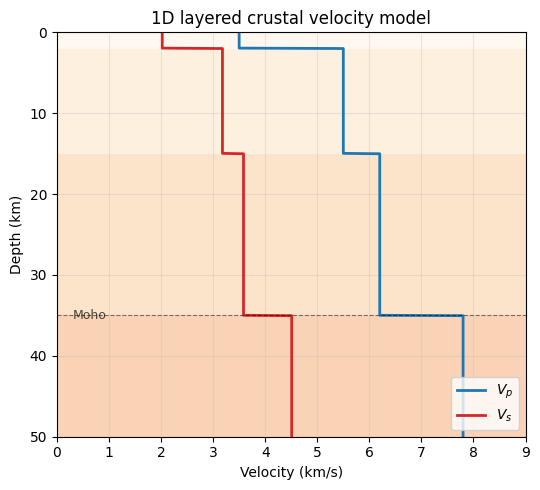

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(5.5, 5.0))
z_plot = np.linspace(0, 50, 1000)
ax.plot(velocity_at(z_plot, VMODEL, 'P'), z_plot, lw=2.0, color='C0', label='$V_p$')
ax.plot(velocity_at(z_plot, VMODEL, 'S'), z_plot, lw=2.0, color='C3', label='$V_s$')

# Shade layers softly.
colors = ['#fef3e3', '#fde2c0', '#fbcb98', '#f7a86e']
for i in range(len(VMODEL['layer_tops'])):
    top = VMODEL['layer_tops'][i]
    bot = VMODEL['layer_tops'][i+1] if i+1 < len(VMODEL['layer_tops']) else 50
    ax.axhspan(top, bot, facecolor=colors[i % len(colors)], alpha=0.5, zorder=0)

# Highlight the Moho.
ax.axhline(35.0, color='k', lw=0.8, ls='--', alpha=0.5)
ax.text(0.3, 35.4, 'Moho', fontsize=9, alpha=0.7)

ax.set_xlabel('Velocity (km/s)')
ax.set_ylabel('Depth (km)')
ax.set_xlim(0, 9)
ax.set_ylim(50, 0)  # depth points down
ax.legend(loc='lower right')
ax.set_title('1D layered crustal velocity model')
plt.tight_layout()
plt.show()

## 2. Travel time of a straight segment crossing layers

Before we can trace rays, we need a primitive: the travel time of a
**straight segment** from $\mathbf{p}_1 = (s_1, z_1)$ to $\mathbf{p}_2 = (s_2, z_2)$
through the layered medium. Here $s$ is horizontal distance along the
source–receiver azimuth (we work in the source–receiver vertical plane).

Within any one layer of velocity $v$, the travel time of a straight piece
of length $\ell$ is just $\ell / v$. If the segment crosses one or more
layer interfaces, we break it at each crossing and add up the pieces:

$$
T = \sum_k \frac{\ell_k}{v_k},
$$

where $\ell_k$ is the length of the segment that lies inside layer $k$.

A clean way to find the crossings: parametrize the segment as
$\mathbf{p}(t) = \mathbf{p}_1 + t (\mathbf{p}_2 - \mathbf{p}_1)$ for $t \in [0, 1]$.
The depth coordinate is linear in $t$, so the segment hits layer top
$z_i$ at $t_i = (z_i - z_1) / (z_2 - z_1)$. Sort the $t_i$ that fall in
$(0, 1)$, prepend $0$, append $1$, and you have the breakpoints.

In [5]:
def segment_travel_time(p1, p2, vmodel, phase='P'):
    '''
    Travel time of a straight segment from p1 = (s, z) to p2 = (s, z)
    through a 1D layered medium. p1, p2 are (2,) arrays in (s, z) [km].
    '''
    p1 = np.asarray(p1, dtype=float)
    p2 = np.asarray(p2, dtype=float)
    seg_len = float(np.hypot(p2[0]-p1[0], p2[1]-p1[1]))
    if seg_len < 1e-12:
        return 0.0

    z1, z2 = float(p1[1]), float(p2[1])

    # Special case: horizontal segment, single layer.
    if abs(z2 - z1) < 1e-12:
        return seg_len / float(velocity_at(z1, vmodel, phase))

    # Layer interfaces strictly inside (z_min, z_max).
    z_min, z_max = (z1, z2) if z1 < z2 else (z2, z1)
    tops = vmodel['layer_tops']
    interfaces = tops[(tops > z_min) & (tops < z_max)]

    # Map each interface depth to a parameter t in (0, 1).
    t_breaks = sorted([(zi - z1) / (z2 - z1) for zi in interfaces])
    t_breaks = [0.0] + t_breaks + [1.0]

    total_tt = 0.0
    for ta, tb in zip(t_breaks[:-1], t_breaks[1:]):
        z_mid = z1 + 0.5 * (ta + tb) * (z2 - z1)
        v = float(velocity_at(z_mid, vmodel, phase))
        total_tt += (tb - ta) * seg_len / v
    return total_tt

**Demonstrate.** Plot a segment from a source at depth 8 km out to a
receiver at the surface 30 km away, with each piece colored by the
velocity of the layer it traverses. The total travel time labels the
segment.

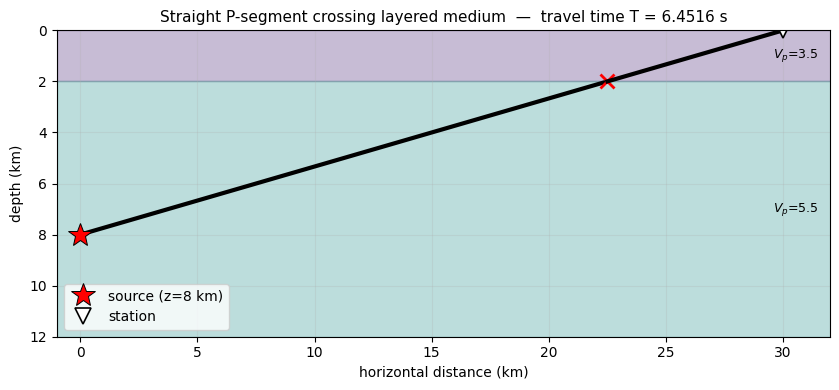

Segment from [0. 8.] to [30.  0.]: T = 6.4516 s (P wave)


In [6]:
fig, ax = plt.subplots(1, 1, figsize=(8.5, 4.0))
p1, p2 = np.array([0.0, 8.0]), np.array([30.0, 0.0])
phase = 'P'

# Shade layers across the whole plot.
zmax = 12
xmax = 32
for i, top in enumerate(VMODEL['layer_tops']):
    bot = VMODEL['layer_tops'][i+1] if i+1 < len(VMODEL['layer_tops']) else zmax
    if top > zmax: break
    bot = min(bot, zmax)
    v = VMODEL['vp'][i]
    color = plt.cm.viridis((v - 3.0) / 5.0)
    ax.add_patch(plt.Rectangle((-1, top), xmax+2, bot-top, color=color, alpha=0.30, zorder=0))
    ax.text(xmax-0.5, 0.5*(top+bot), f'$V_p$={v:.1f}', ha='right', va='center', fontsize=9)

# Find layer crossings for the segment and split into colored pieces.
z1, z2 = p1[1], p2[1]
z_min, z_max = min(z1, z2), max(z1, z2)
tops = VMODEL['layer_tops']
interfaces = tops[(tops > z_min) & (tops < z_max)]
t_breaks = sorted([(zi - z1) / (z2 - z1) for zi in interfaces])
t_breaks = [0.0] + t_breaks + [1.0]

for ta, tb in zip(t_breaks[:-1], t_breaks[1:]):
    pa = p1 + ta * (p2 - p1)
    pb = p1 + tb * (p2 - p1)
    z_mid = 0.5 * (pa[1] + pb[1])
    v = velocity_at(z_mid, VMODEL, phase)
    ax.plot([pa[0], pb[0]], [pa[1], pb[1]], lw=3.0, color='k')
    # Mark interfaces with crosses.
    if tb < 1.0:
        ax.plot(pb[0], pb[1], 'rx', ms=10, mew=2)
ax.plot(*p1, 'r*', ms=18, mec='k', mew=0.7, label='source (z=8 km)')
ax.plot(*p2, 'kv', ms=12, mec='k', mfc='w', mew=1.2, label='station')

tt = segment_travel_time(p1, p2, VMODEL, phase=phase)
ax.set_title(f'Straight {phase}-segment crossing layered medium  —  '
             f'travel time T = {tt:.4f} s', fontsize=11)
ax.set_xlabel('horizontal distance (km)')
ax.set_ylabel('depth (km)')
ax.set_xlim(-1, xmax)
ax.set_ylim(zmax, 0)
ax.legend(loc='lower left')
plt.tight_layout()
plt.show()

print(f'Segment from {p1} to {p2}: T = {tt:.4f} s ({phase} wave)')

## 3. Pseudo-bending: enforcing Fermat's principle iteratively

A *straight* line from source to receiver is not the actual ray path —
the real ray bends into faster layers to *minimize* travel time. This is
**Fermat's principle**:

$$
\delta T \,/\, \delta(\text{path}) = 0
$$

— the true ray is a *stationary* path of $T$.

**Pseudo-bending** (Um & Thurber, 1987) discretizes the ray as $N$ nodes
$\mathbf{P}_0, \mathbf{P}_1, \ldots, \mathbf{P}_{N-1}$ and enforces Fermat
locally, one node at a time. For each interior node $\mathbf{P}_k$:

1. Form the **chord** from its two neighbours: $\mathbf{c} = \mathbf{P}_{k+1} - \mathbf{P}_{k-1}$.
2. Build a unit **normal** $\hat{\mathbf{n}}$ in the source–receiver plane,
   perpendicular to $\mathbf{c}$.
3. Move $\mathbf{P}_k$ along $\hat{\mathbf{n}}$ to the position that minimizes
   the two-segment travel time $T_{k-1,k} + T_{k,k+1}$.

Sweep all interior nodes. Repeat sweeps until the total travel time stops
changing. The rays naturally bow into faster layers because that's where
the perpendicular optimum sits.

**Why perpendicular only?** Moving a node *along* the chord just shifts
it along the existing ray — it doesn't change the path shape, only the
node parameterization. The perpendicular direction is the only way to
deform the ray, and it's the direction along which Fermat actually
imposes a condition.

**Refinement.** In a piecewise-constant medium the *exact* ray has
sharp kinks at each layer interface (Snell's law). With $N$ regularly-
spaced nodes there's no guarantee a node lands near a kink, and travel
time can be a few tens of milliseconds off the exact answer. The
standard fix is *refinement*: after the iterations converge, double
the node count by inserting midpoints between consecutive nodes, and
iterate again. This lets the path adapt to interfaces. Two refinement
rounds (so 21 → 41 → 81 nodes) brings agreement with the exact
analytical solution well below the 10-ms sample interval.

In [7]:
def perturb_node(p_prev, p_curr, p_next, vmodel, phase='P'):
    '''
    Move p_curr perpendicular to (p_next - p_prev) to minimize the sum of
    the two adjacent segment travel times. Returns the new position.
    '''
    chord = p_next - p_prev
    chord_len = float(np.linalg.norm(chord))
    if chord_len < 1e-12:
        return p_curr.copy()
    t_hat = chord / chord_len
    n_hat = np.array([-t_hat[1], t_hat[0]])      # 2D perpendicular
    midpoint = 0.5 * (p_prev + p_next)
    bound = 0.5 * chord_len

    def two_seg_tt(s):
        p = midpoint + s * n_hat
        if p[1] < 0.0:                # forbid rising above the free surface
            p = np.array([p[0], 0.0])
        return (segment_travel_time(p_prev, p, vmodel, phase)
                + segment_travel_time(p, p_next, vmodel, phase))

    res = minimize_scalar(two_seg_tt, bounds=(-bound, bound),
                          method='bounded', options={'xatol': 1e-4})
    new_p = midpoint + res.x * n_hat
    if new_p[1] < 0.0:
        new_p[1] = 0.0
    return new_p


def trace_ray(source, receiver, vmodel, phase='P',
              n_nodes=21, max_iter=80, tol=1e-6,
              refinement_levels=1, record_history=False):
    '''
    Pseudo-bending ray trace from source to receiver in a 1D layered model.

    source, receiver : (3,) arrays (x, y, z) in km.
    n_nodes          : initial number of nodes (>= 3).
    refinement_levels: after convergence, double the nodes (insert
                       midpoints) this many times and re-converge.
                       Crucial for sub-sample accuracy in piecewise-
                       constant media: nodes need to fall near layer
                       interfaces, and refinement lets them migrate there.

    Returns dict with 'path' (Nx3), 'path_2d', 'travel_time',
    'iterations', 'converged', 'phase', and optionally 'history'.
    '''
    source, receiver = np.asarray(source, float), np.asarray(receiver, float)
    dx, dy = receiver[0] - source[0], receiver[1] - source[1]
    horiz = float(np.hypot(dx, dy))
    azimuth = float(np.arctan2(dy, dx)) if horiz > 0 else 0.0

    p_src_2d = np.array([0.0, source[2]])
    p_rec_2d = np.array([horiz, receiver[2]])
    t = np.linspace(0, 1, n_nodes)
    path_2d = np.outer(1 - t, p_src_2d) + np.outer(t, p_rec_2d)

    history = [path_2d.copy()] if record_history else None

    def total_tt(P):
        return sum(segment_travel_time(P[i], P[i+1], vmodel, phase)
                   for i in range(len(P) - 1))

    total_iters = 0
    converged = False
    for level in range(refinement_levels + 1):
        prev_tt = total_tt(path_2d)
        for it in range(max_iter):
            for k in range(1, len(path_2d) - 1):
                path_2d[k] = perturb_node(path_2d[k-1], path_2d[k],
                                          path_2d[k+1], vmodel, phase)
            new_tt = total_tt(path_2d)
            total_iters += 1
            if record_history:
                history.append(path_2d.copy())
            if abs(prev_tt - new_tt) < tol:
                converged = True
                break
            prev_tt = new_tt
        # Refine: insert midpoint between every consecutive pair of nodes.
        if level < refinement_levels:
            n = len(path_2d)
            new_n = 2 * n - 1
            refined = np.empty((new_n, 2))
            refined[0::2] = path_2d
            refined[1::2] = 0.5 * (path_2d[:-1] + path_2d[1:])
            path_2d = refined

    # Lift back to 3D.
    n = len(path_2d)
    path_3d = np.zeros((n, 3))
    path_3d[:, 0] = source[0] + path_2d[:, 0] * np.cos(azimuth)
    path_3d[:, 1] = source[1] + path_2d[:, 0] * np.sin(azimuth)
    path_3d[:, 2] = path_2d[:, 1]

    out = {
        'path': path_3d,
        'path_2d': path_2d,
        'travel_time': total_tt(path_2d),
        'iterations': total_iters,
        'converged': converged,
        'phase': phase,
    }
    if record_history:
        out['history'] = history
    return out

**Watch pseudo-bending converge.** Below we record every iteration and
plot the path evolving from the initial straight line into the curved
ray that picks up speed in the faster layer below. Notice how the ray
*bows downward* — that's Fermat: a longer path through a faster medium
is faster overall than a shorter path through a slower medium.

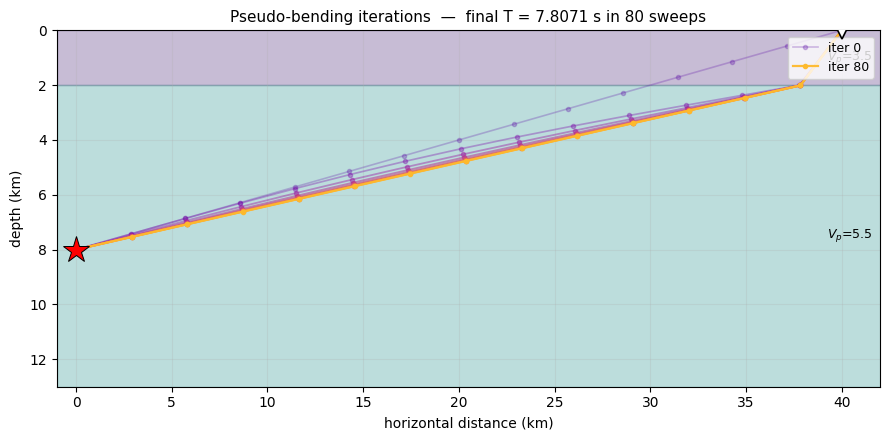

Path nodes: 15
Travel time history (first 5, last 1):
  iter 0..4: ['8.4763', '7.8251', '7.8193', '7.8169', '7.8155']
  iter 80: 7.8071


In [8]:
src_3d = np.array([0.0, 0.0, 8.0])
rec_3d = np.array([40.0, 0.0, 0.0])
result = trace_ray(src_3d, rec_3d, VMODEL, phase='P',
                   n_nodes=15, refinement_levels=0,
                   record_history=True)

fig, ax = plt.subplots(1, 1, figsize=(9.0, 4.5))

# Background layer shading.
zmax, xmax = 13, 42
for i, top in enumerate(VMODEL['layer_tops']):
    bot = VMODEL['layer_tops'][i+1] if i+1 < len(VMODEL['layer_tops']) else zmax
    if top > zmax: break
    bot = min(bot, zmax)
    v = VMODEL['vp'][i]
    color = plt.cm.viridis((v - 3.0) / 5.0)
    ax.add_patch(plt.Rectangle((-1, top), xmax+2, bot-top, color=color,
                                alpha=0.30, zorder=0))
    ax.text(xmax-0.4, 0.5*(top+bot), f'$V_p$={v:.1f}',
            ha='right', va='center', fontsize=9)

# Plot every Kth iteration in fading color.
hist = result['history']
n_it = len(hist)
shown = list(range(0, n_it, max(1, n_it // 8))) + [n_it - 1]
shown = sorted(set(shown))
cmap = plt.cm.plasma
for i, k in enumerate(shown):
    P = hist[k]
    alpha = 0.25 + 0.7 * (i / max(1, len(shown) - 1))
    color = cmap(0.15 + 0.7 * (i / max(1, len(shown) - 1)))
    label = f'iter {k}' if k in (0, n_it - 1) else None
    ax.plot(P[:, 0], P[:, 1], '-o', ms=3, lw=1.2 + 0.05*i,
            color=color, alpha=alpha, label=label)

ax.plot(*result['path_2d'][0], 'r*', ms=20, mec='k', mew=0.7, zorder=10)
ax.plot(*result['path_2d'][-1], 'kv', ms=13, mec='k', mfc='w', mew=1.2, zorder=10)
ax.set_xlim(-1, xmax)
ax.set_ylim(zmax, 0)
ax.set_xlabel('horizontal distance (km)')
ax.set_ylabel('depth (km)')
ax.legend(loc='upper right', fontsize=9)
ax.set_title(f'Pseudo-bending iterations  —  '
             f'final T = {result["travel_time"]:.4f} s in '
             f'{result["iterations"]} sweeps', fontsize=11)
plt.tight_layout()
plt.show()

print(f'Path nodes: {len(result["path_2d"])}')
print(f'Travel time history (first 5, last 1):')
hist_tt = []
for P in hist:
    tt = sum(segment_travel_time(P[i], P[i+1], VMODEL, 'P') for i in range(len(P)-1))
    hist_tt.append(tt)
print('  iter 0..4:', [f'{x:.4f}' for x in hist_tt[:5]])
print(f'  iter {len(hist_tt)-1}: {hist_tt[-1]:.4f}')

## 4. Sanity check: pseudo-bending vs analytical Snell-law solution

In a 1D layered medium there is an *exact* solution we can check
pseudo-bending against. **Snell's law** says the ray parameter

$$
p \;=\; \frac{\sin i}{v}
$$

is conserved across all layers. In layer $k$ with velocity $v_k$ the ray
makes angle $i_k$ with vertical, where $\sin i_k = p\,v_k$. A layer of
thickness $h_k$ contributes

$$
X_k(p) = h_k \frac{p\,v_k}{\sqrt{1 - p^2 v_k^2}}, \qquad
T_k(p) = \frac{h_k}{v_k\sqrt{1 - p^2 v_k^2}}
$$

to horizontal distance and travel time, respectively. Solve
$X(p) = \sum_k X_k(p)$ for $p$ to match the desired horizontal distance,
then evaluate $T(p)$.

This is *much* faster than pseudo-bending — a single 1D root find — and
exact (to the root finder's tolerance). We'll use this for the
inversion later. Pseudo-bending is the more general tool (works in 3D
heterogeneous media); the analytical solution exists only because our
medium is 1D.

In [9]:
def travel_time_layered(horiz_dist, source_depth, vmodel, phase='P'):
    '''
    Analytical direct-ray travel time from source at (horiz_dist, source_depth)
    to receiver at (0, 0). Uses Snell ray parameter.
    '''
    velocities_full = vmodel['vp'] if phase.upper() == 'P' else vmodel['vs']
    tops = vmodel['layer_tops']

    # Build layer thicknesses traversed by the upgoing ray.
    if source_depth <= 0:
        return 0.0
    ks = int(np.searchsorted(tops, source_depth, side='right') - 1)
    ks = max(0, min(ks, len(tops) - 1))
    thicks, vs = [source_depth - tops[ks]], [velocities_full[ks]]
    for i in range(ks - 1, -1, -1):
        thicks.append(tops[i+1] - tops[i])
        vs.append(velocities_full[i])
    thicks, vs = np.array(thicks), np.array(vs)

    if horiz_dist < 1e-9:
        return float(np.sum(thicks / vs))

    p_max = 1.0 / float(np.max(vs)) - 1e-9

    def X_minus_target(p):
        sini = p * vs
        if np.any(sini >= 1.0): return np.inf
        cosi = np.sqrt(1.0 - sini * sini)
        return float(np.sum(thicks * sini / cosi)) - horiz_dist

    if X_minus_target(p_max) < 0:
        # Beyond direct-ray reach. For our 60-km network and 5–15 km
        # source depths this never triggers in practice.
        raise ValueError(f'No direct ray for horiz={horiz_dist}, depth={source_depth}')

    p_opt = brentq(X_minus_target, 0.0, p_max, xtol=1e-9)
    sini = p_opt * vs
    cosi = np.sqrt(1.0 - sini * sini)
    return float(np.sum(thicks / (vs * cosi)))

**Compare.** Sweep horizontal distances from 5 to 60 km, compute travel
time both ways, and plot the two curves and their difference. Agreement
should be at the millisecond level — fully adequate for picking arrivals
sampled at $\Delta t = 0.01$ s.

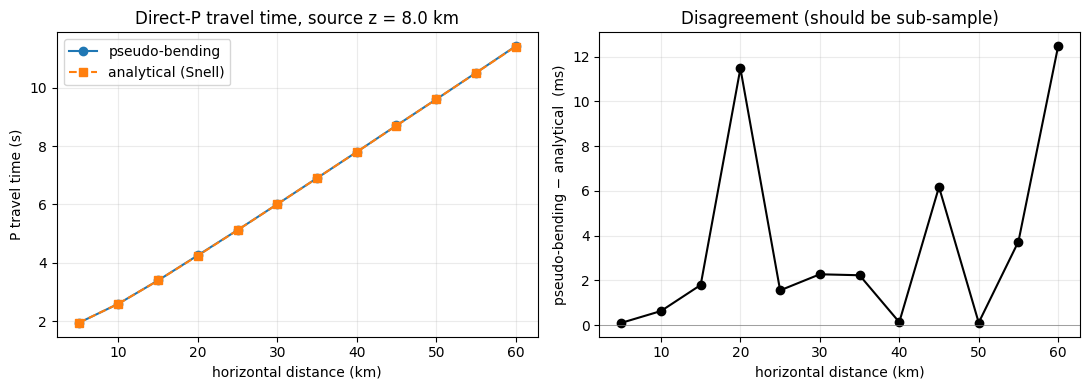

Max disagreement: 12.465 ms (sample interval is 10 ms)


In [10]:
distances = np.linspace(5, 60, 12)
src_depth = 8.0

tt_pb = np.empty_like(distances)
tt_an = np.empty_like(distances)
for i, d in enumerate(distances):
    src = np.array([0.0, 0.0, src_depth])
    rec = np.array([d, 0.0, 0.0])
    tt_pb[i] = trace_ray(src, rec, VMODEL, phase='P',
                         n_nodes=21, max_iter=80,
                         refinement_levels=2)['travel_time']
    tt_an[i] = travel_time_layered(d, src_depth, VMODEL, phase='P')

fig, axs = plt.subplots(1, 2, figsize=(11, 4))
ax = axs[0]
ax.plot(distances, tt_pb, 'o-', label='pseudo-bending', lw=1.5)
ax.plot(distances, tt_an, 's--', label='analytical (Snell)', lw=1.5)
ax.set_xlabel('horizontal distance (km)')
ax.set_ylabel('P travel time (s)')
ax.set_title(f'Direct-P travel time, source z = {src_depth} km')
ax.legend()

ax = axs[1]
ax.plot(distances, (tt_pb - tt_an) * 1000, 'ko-', lw=1.5)
ax.axhline(0, color='gray', lw=0.5)
ax.set_xlabel('horizontal distance (km)')
ax.set_ylabel('pseudo-bending − analytical  (ms)')
ax.set_title('Disagreement (should be sub-sample)')
plt.tight_layout()
plt.show()

print(f'Max disagreement: {np.max(np.abs(tt_pb - tt_an)) * 1000:.3f} ms '
      f'(sample interval is 10 ms)')

## 5. Double-couple source: the moment tensor

Earthquakes on planar faults are well-described by a **double-couple**
(DC) source. The fault geometry is specified by three angles
(Aki & Richards convention):

- $\phi_s$ (**strike**): azimuth of the fault trace, clockwise from North, $0$–$360°$.
- $\delta$ (**dip**): inclination of the fault from horizontal, $0$–$90°$.
- $\lambda$ (**rake**): direction of slip *of the hanging wall* in the fault plane, measured from strike. $\lambda = 0$ is left-lateral strike-slip, $\lambda = 90°$ is pure thrust, $\lambda = -90°$ is pure normal.

The source radiation is encoded in the symmetric **moment tensor**
$\mathbf{M}$ ($3 \times 3$). For a pure DC, in $(N, E, D)$ coordinates
(Aki & Richards, eq. 4.29):

$$
\begin{aligned}
M_{NN} &= -M_0 (\sin\delta\cos\lambda \sin 2\phi_s + \sin 2\delta \sin\lambda \sin^2\phi_s) \\
M_{EE} &=  M_0 (\sin\delta\cos\lambda \sin 2\phi_s - \sin 2\delta \sin\lambda \cos^2\phi_s) \\
M_{DD} &=  M_0 \sin 2\delta \sin\lambda \\
M_{NE} &=  M_0 (\sin\delta\cos\lambda \cos 2\phi_s + \tfrac{1}{2}\sin 2\delta \sin\lambda \sin 2\phi_s) \\
M_{ND} &= -M_0 (\cos\delta\cos\lambda \cos\phi_s + \cos 2\delta \sin\lambda \sin\phi_s) \\
M_{ED} &= -M_0 (\cos\delta\cos\lambda \sin\phi_s - \cos 2\delta \sin\lambda \cos\phi_s)
\end{aligned}
$$

A pure DC tensor has eigenvalues $(-M_0, 0, +M_0)$ — equal-and-opposite
P (compressional) and T (tensional) axes, no isotropic component. We'll
verify this below.

In [11]:
def moment_tensor_sdr(strike_deg, dip_deg, rake_deg, M0=1.0):
    '''3x3 moment tensor (Aki & Richards) in (N, E, Down) coords.'''
    phi   = np.deg2rad(strike_deg)
    delta = np.deg2rad(dip_deg)
    lam   = np.deg2rad(rake_deg)
    sf, cf, sl, cl = np.sin(phi), np.cos(phi), np.sin(lam), np.cos(lam)
    sd, cd = np.sin(delta), np.cos(delta)
    s2f, c2f = np.sin(2*phi), np.cos(2*phi)
    s2d, c2d = np.sin(2*delta), np.cos(2*delta)

    M_NN = -M0 * (sd*cl*s2f + s2d*sl*sf*sf)
    M_EE =  M0 * (sd*cl*s2f - s2d*sl*cf*cf)
    M_DD =  M0 * (s2d*sl)
    M_NE =  M0 * (sd*cl*c2f + 0.5*s2d*sl*s2f)
    M_ND = -M0 * (cd*cl*cf + c2d*sl*sf)
    M_ED = -M0 * (cd*cl*sf - c2d*sl*cf)
    return np.array([
        [M_NN, M_NE, M_ND],
        [M_NE, M_EE, M_ED],
        [M_ND, M_ED, M_DD],
    ])


# Quick sanity: a pure DC has eigenvalues (-M0, 0, M0) and zero trace.
M_test = moment_tensor_sdr(strike_deg=30, dip_deg=60, rake_deg=-90, M0=1.0)
print('Test moment tensor (strike=30, dip=60, rake=-90, normal fault):')
print(M_test)
print(f'  trace = {np.trace(M_test):+.2e}  (should be ~0 for pure DC)')
print(f'  eigenvalues = {np.sort(np.linalg.eigvalsh(M_test))}  (should be -1, 0, +1)')

Test moment tensor (strike=30, dip=60, rake=-90, normal fault):
[[ 0.2165 -0.375  -0.25  ]
 [-0.375   0.6495  0.433 ]
 [-0.25    0.433  -0.866 ]]
  trace = +0.00e+00  (should be ~0 for pure DC)
  eigenvalues = [-1.  0.  1.]  (should be -1, 0, +1)


**Visualize the focal mechanism — the "beachball" plot.**

A beachball is a stereographic projection of the lower focal hemisphere,
shaded by sign of P-wave first motion. Each direction $\hat{\boldsymbol\gamma}$
on the sphere has P amplitude $\hat{\boldsymbol\gamma}^T \mathbf{M}\, \hat{\boldsymbol\gamma}$.
Compressional (positive) regions are filled black, dilatational
(negative) white. The two curves separating them are the two **nodal
planes** — one is the fault, the other is the *auxiliary plane*
(geometrically indistinguishable from a single observation set).

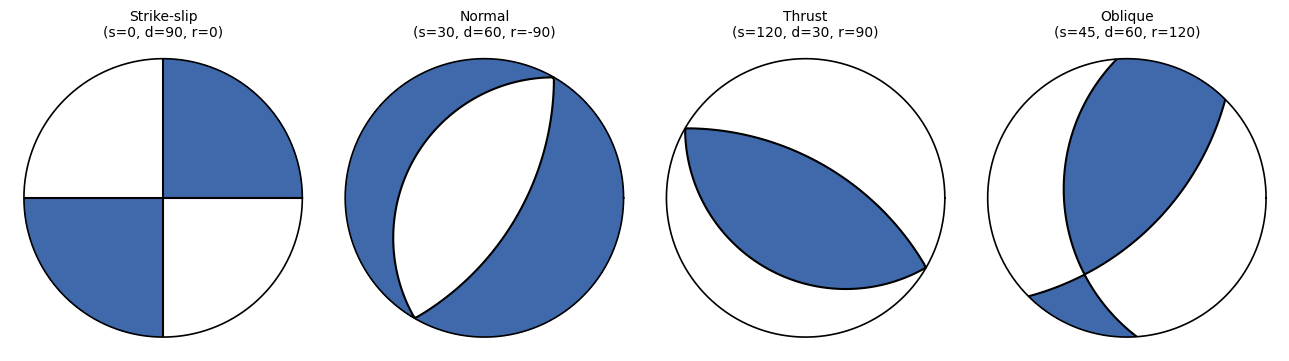

In [12]:
def beachball(M, ax, n=200, fill_color='#1d4f9c', radius=1.0):
    '''Lower-hemisphere stereographic beachball plot of moment tensor M.'''
    th = np.linspace(0, 2*np.pi, 720)
    ax.plot(radius*np.cos(th), radius*np.sin(th), 'k-', lw=1.2)

    # Sample lower hemisphere directions: takeoff i in [0, pi/2], azimuth phi in [0, 2pi].
    # Lower hemisphere stereographic: rho = R * tan(i / 2). Equivalent to
    # plotting where the downgoing ray pierces a horizontal plane below the source.
    grid_i = np.linspace(0.001, np.pi/2 - 0.001, n)
    grid_phi = np.linspace(0, 2*np.pi, 2*n)
    I, Phi = np.meshgrid(grid_i, grid_phi)
    # Direction in (N, E, D), takeoff from down (i=0 -> straight down).
    gx = np.sin(I) * np.cos(Phi)   # N
    gy = np.sin(I) * np.sin(Phi)   # E
    gz = np.cos(I)                  # D (positive)
    # P amplitude.
    Fp = (M[0,0]*gx*gx + M[1,1]*gy*gy + M[2,2]*gz*gz
          + 2*M[0,1]*gx*gy + 2*M[0,2]*gx*gz + 2*M[1,2]*gy*gz)
    # Stereographic radius (lower hemisphere, equal-area would be sin(i/2)*sqrt(2)).
    rho = radius * np.tan(I / 2.0) / np.tan(np.pi/4)
    X, Y = rho * np.sin(Phi), rho * np.cos(Phi)  # E to right, N up
    # Compressional regions filled.
    ax.contourf(X, Y, Fp, levels=[0, np.inf], colors=[fill_color], alpha=0.85)
    ax.contour(X, Y, Fp, levels=[0], colors='k', linewidths=1.5)
    ax.set_xlim(-radius*1.1, radius*1.1)
    ax.set_ylim(-radius*1.1, radius*1.1)
    ax.set_aspect('equal')
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values(): spine.set_visible(False)


fig, axs = plt.subplots(1, 4, figsize=(13, 3.8))
mechs = [
    ('Strike-slip\n(s=0, d=90, r=0)',   (0,   90,   0)),
    ('Normal\n(s=30, d=60, r=-90)',    (30,  60, -90)),
    ('Thrust\n(s=120, d=30, r=90)',    (120, 30,  90)),
    ('Oblique\n(s=45, d=60, r=120)',   (45,  60, 120)),
]
for ax, (label, sdr) in zip(axs, mechs):
    M = moment_tensor_sdr(*sdr, M0=1.0)
    beachball(M, ax)
    ax.set_title(label, fontsize=10)
    # North arrow
    ax.annotate('N', xy=(0, 1.18), ha='center', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Radiation pattern: P, SV, SH amplitudes

The P-wave amplitude radiated in direction $\hat{\boldsymbol\gamma}$
(unit takeoff vector) is

$$
F^P(\hat{\boldsymbol\gamma}) = \hat{\boldsymbol\gamma}^T \mathbf{M}\, \hat{\boldsymbol\gamma}.
$$

The S-wave is a vector quantity perpendicular to $\hat{\boldsymbol\gamma}$:

$$
\mathbf{F}^S(\hat{\boldsymbol\gamma}) = \mathbf{M}\hat{\boldsymbol\gamma} - \bigl(\hat{\boldsymbol\gamma}^T \mathbf{M}\, \hat{\boldsymbol\gamma}\bigr)\hat{\boldsymbol\gamma}.
$$

We split $\mathbf{F}^S$ into:

- **SV**: lies in the *vertical plane* containing the ray (the source–receiver plane). In-plane shear motion.
- **SH**: *horizontal*, perpendicular to that plane. Out-of-plane shear motion.

The SV/SH split matters because the receiver records 3 components
(Z, N, E), and we need to project source-side amplitudes to the right
combinations.

In [13]:
def radiation_pattern(M, takeoff_dir):
    '''
    P, SV, SH radiation amplitudes for moment tensor M radiating
    in unit direction takeoff_dir = (g_N, g_E, g_D).
    Returns (F_P, F_SV, F_SH).
    '''
    g = np.asarray(takeoff_dir, dtype=float)
    g = g / np.linalg.norm(g)
    F_P = float(g @ M @ g)
    s_vec = M @ g - F_P * g

    g_h = np.array([g[0], g[1], 0.0])
    g_h_norm = float(np.linalg.norm(g_h))
    if g_h_norm < 1e-9:
        sh = np.array([0.0, 1.0, 0.0])
        sv = np.array([1.0, 0.0, 0.0])
    else:
        sh = np.array([-g_h[1], g_h[0], 0.0]) / g_h_norm
        sv = np.cross(sh, g)
        sv = sv / np.linalg.norm(sv)
    F_SV = float(s_vec @ sv)
    F_SH = float(s_vec @ sh)
    return F_P, F_SV, F_SH

**Plot the P-wave radiation pattern as a function of azimuth.** Pick a
reference takeoff angle (say 60° from down) and step around the source
in azimuth. A pure DC always gives the classic 4-lobed pattern with
sign changes at the nodal planes.

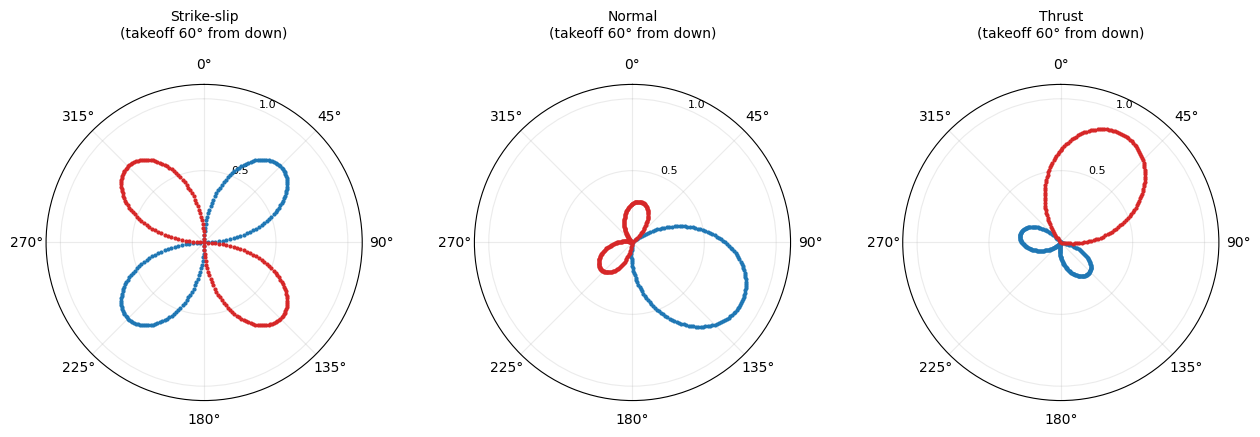

In [14]:
fig, axs = plt.subplots(1, 3, figsize=(13, 4.2),
                        subplot_kw=dict(projection='polar'))
takeoff_from_down_deg = 60.0
take = np.deg2rad(takeoff_from_down_deg)
azimuths = np.linspace(0, 2*np.pi, 361)

mechs = [
    ('Strike-slip', (0, 90, 0)),
    ('Normal',      (30, 60, -90)),
    ('Thrust',      (120, 30, 90)),
]
for ax, (label, sdr) in zip(axs, mechs):
    M = moment_tensor_sdr(*sdr)
    fp = []
    for az in azimuths:
        g = np.array([np.sin(take)*np.cos(az), np.sin(take)*np.sin(az), np.cos(take)])
        F_P, _, _ = radiation_pattern(M, g)
        fp.append(F_P)
    fp = np.array(fp)
    # Plot |F_P| with color indicating sign.
    pos = fp >= 0
    ax.plot(azimuths[pos], np.abs(fp[pos]), 'o', ms=2, color='C0', label='F_P > 0')
    ax.plot(azimuths[~pos], np.abs(fp[~pos]), 'o', ms=2, color='C3', label='F_P < 0')
    ax.set_title(f'{label}\n(takeoff {takeoff_from_down_deg:.0f}° from down)',
                 fontsize=10, pad=15)
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    ax.set_rlim(0, 1.1)
    ax.set_yticks([0.5, 1.0])
    ax.set_yticklabels(['0.5', '1.0'], fontsize=8)
plt.tight_layout()
plt.show()

## 7. Multiple phases: Pg, Sg, PmP, SmS

A real local-event seismogram contains more than just the direct P and
S arrivals. Significant later arrivals come from energy that bounces off
internal interfaces, especially the **Moho** (35 km in our model).

We model four phases here:

- **Pg, Sg** — direct P and S (we already have these via `trace_ray`).
- **PmP, SmS** — P and S that go *down* to the Moho, reflect, and come
  *up* to the receiver.

For PmP/SmS the path is two pseudo-bending traces glued together at a
bounce point on the Moho. The horizontal position of the bounce point
is found by 1D minimization of the total two-leg time (Fermat again).

> **Note on free-surface reflections (pP, sS).** For receivers *on the
> free surface* ($z = 0$), pP and sS degenerate: the optimal bounce
> point migrates to the receiver itself, and the path collapses onto
> the direct ray. They become distinct arrivals only for buried
> receivers or teleseismic geometries. We don't include them here.

In [15]:
def trace_moho_reflection(source, receiver, vmodel,
                          interface_z=35.0,
                          phase_down='P', phase_up='P',
                          n_nodes=11, max_iter=60):
    '''
    Trace a ray that goes down from source to ``interface_z``, reflects,
    and comes up to receiver. With phase_down=phase_up='P' this gives PmP;
    with 'S','S' SmS. Returns dict like trace_ray.
    '''
    source, receiver = np.asarray(source, float), np.asarray(receiver, float)
    if source[2] >= interface_z or receiver[2] >= interface_z:
        raise ValueError('Source/receiver must be shallower than interface_z.')
    dx, dy = receiver[0] - source[0], receiver[1] - source[1]
    horiz = float(np.hypot(dx, dy))
    azimuth = float(np.arctan2(dy, dx)) if horiz > 0 else 0.0

    def bounce_3d(s_b):
        return np.array([source[0] + s_b*np.cos(azimuth),
                         source[1] + s_b*np.sin(azimuth), interface_z])

    def total_tt(s_b):
        bp = bounce_3d(s_b)
        l1 = trace_ray(source, bp, vmodel, phase_down, n_nodes=n_nodes,
                       max_iter=max_iter)['travel_time']
        l2 = trace_ray(bp, receiver, vmodel, phase_up, n_nodes=n_nodes,
                       max_iter=max_iter)['travel_time']
        return l1 + l2

    # Coarse-to-fine bracketing of the bounce-point horizontal coord.
    s_grid = np.linspace(0.0, horiz, 11)
    tt_grid = np.array([total_tt(s) for s in s_grid])
    k = int(np.argmin(tt_grid))
    res = minimize_scalar(total_tt,
                          bounds=(s_grid[max(k-1,0)], s_grid[min(k+1,len(s_grid)-1)]),
                          method='bounded', options={'xatol': 1e-3})
    s_b = float(res.x)
    bp = bounce_3d(s_b)
    leg1 = trace_ray(source, bp, vmodel, phase_down, n_nodes=n_nodes, max_iter=max_iter)
    leg2 = trace_ray(bp, receiver, vmodel, phase_up, n_nodes=n_nodes, max_iter=max_iter)
    full_path = np.vstack([leg1['path'], leg2['path'][1:]])
    label_map = {('P','P'):'PmP', ('S','S'):'SmS', ('P','S'):'PmS', ('S','P'):'SmP'}
    return {
        'path': full_path,
        'travel_time': leg1['travel_time'] + leg2['travel_time'],
        'phase': phase_up,
        'label': label_map.get((phase_down, phase_up), f'{phase_down}m{phase_up}'),
    }

**Trace all four phases for one source–station pair** and plot them in
the source–receiver vertical section. Travel times come out in the
order Pg < PmP (sometimes < Sg, sometimes > Sg) < SmS, with the order
of PmP and Sg crossing over depending on offset.

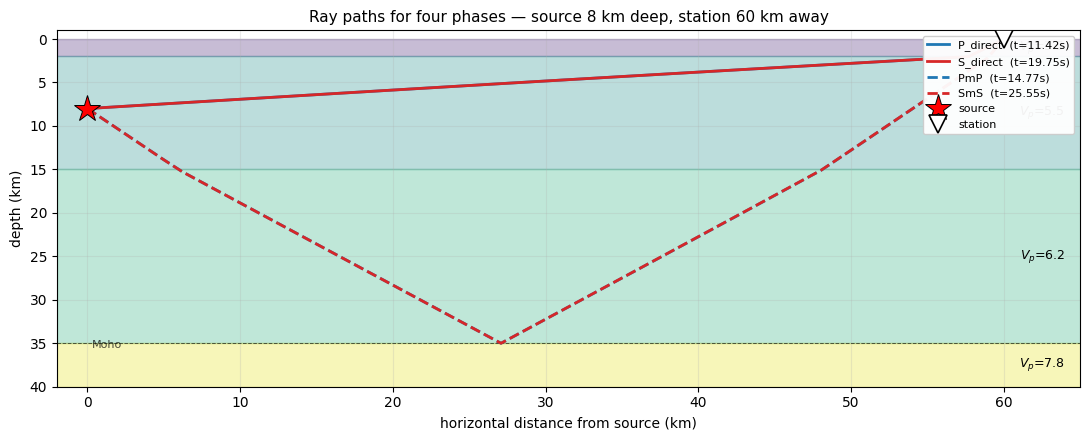

Travel times:
  Pg  = 11.418 s
  Sg  = 19.754 s
  PmP = 14.767 s   (PmP - Pg = 3.349s)
  SmS = 25.547 s   (SmS - Sg = 5.794s)


In [16]:
src = np.array([0.0, 0.0, 8.0])
rec = np.array([60.0, 0.0, 0.0])  # 60 km offset

Pg  = trace_ray(src, rec, VMODEL, phase='P', n_nodes=21)
Sg  = trace_ray(src, rec, VMODEL, phase='S', n_nodes=21)
PmP = trace_moho_reflection(src, rec, VMODEL, phase_down='P', phase_up='P')
SmS = trace_moho_reflection(src, rec, VMODEL, phase_down='S', phase_up='S')

# Plot in source-receiver vertical section.
fig, ax = plt.subplots(1, 1, figsize=(11, 4.5))
zmax, xmax = 40, 65
for i, top in enumerate(VMODEL['layer_tops']):
    bot = VMODEL['layer_tops'][i+1] if i+1 < len(VMODEL['layer_tops']) else zmax
    if top > zmax: break
    bot = min(bot, zmax)
    v = VMODEL['vp'][i]
    color = plt.cm.viridis((v - 3.0) / 5.0)
    ax.add_patch(plt.Rectangle((-2, top), xmax+4, bot-top, color=color, alpha=0.30, zorder=0))
    ax.text(xmax-1, 0.5*(top+bot), f'$V_p$={v:.1f}', ha='right', va='center', fontsize=9)
ax.axhline(35, color='k', lw=0.7, ls='--', alpha=0.6)
ax.text(0.3, 35.6, 'Moho', fontsize=8, alpha=0.7)

# Ray paths in (s, z): use horizontal distance along source-receiver line.
def proj2d(path, src):
    s = np.linalg.norm(path[:, :2] - src[:2], axis=1)
    return s, path[:, 2]

for ph, color, ls in [(Pg, 'C0', '-'), (Sg, 'C3', '-'),
                      (PmP, 'C0', '--'), (SmS, 'C3', '--')]:
    s_arr, z_arr = proj2d(ph['path'], src)
    label = ph.get('label', ph['phase'] + '_direct')
    label = f"{label}  (t={ph['travel_time']:.2f}s)"
    ax.plot(s_arr, z_arr, color=color, ls=ls, lw=2.0, label=label, zorder=3)

ax.plot(0, src[2], 'r*', ms=20, mec='k', mew=0.7, zorder=10, label='source')
ax.plot(60, 0, 'kv', ms=13, mec='k', mfc='w', mew=1.2, zorder=10, label='station')
ax.set_xlim(-2, xmax)
ax.set_ylim(zmax, -1)
ax.set_xlabel('horizontal distance from source (km)')
ax.set_ylabel('depth (km)')
ax.set_title('Ray paths for four phases — source 8 km deep, station 60 km away',
             fontsize=11)
ax.legend(loc='upper right', fontsize=8, framealpha=0.95)
plt.tight_layout()
plt.show()

print(f'Travel times:')
print(f'  Pg  = {Pg["travel_time"]:.3f} s')
print(f'  Sg  = {Sg["travel_time"]:.3f} s')
print(f'  PmP = {PmP["travel_time"]:.3f} s   (PmP - Pg = {PmP["travel_time"]-Pg["travel_time"]:.3f}s)')
print(f'  SmS = {SmS["travel_time"]:.3f} s   (SmS - Sg = {SmS["travel_time"]-Sg["travel_time"]:.3f}s)')

## 8. Source time function: Brune model

The earthquake doesn't release its energy instantaneously. We use a
**Brune-type causal source time function**:

$$
s(t) \;=\; M_0\,\sigma^2\, t \,\exp(-\sigma t), \quad t \geq 0,
\qquad \sigma = 2\pi f_c.
$$

It rises from zero, peaks at $t = 1/\sigma$, then decays. $f_c$ is the
**corner frequency** (Hz). For local earthquakes, $f_c \sim 1$–5 Hz.

Causality matters for picking: a causal STF starts cleanly at
$t = T_\text{arrival}$. A symmetric wavelet (Ricker / Mexican-hat) would
have *pre-arrival* energy that confuses the eye and biases picks.

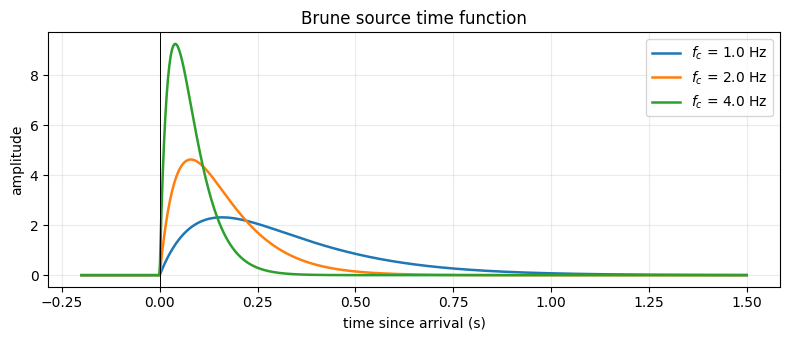

In [17]:
def brune_stf(t, fc=2.0, M0=1.0):
    '''Causal Brune source-time-function impulse response.'''
    sigma = 2.0 * np.pi * fc
    s = np.zeros_like(t, dtype=float)
    mask = t >= 0
    s[mask] = M0 * sigma * sigma * t[mask] * np.exp(-sigma * t[mask])
    return s

# Plot for a few corner frequencies.
fig, ax = plt.subplots(1, 1, figsize=(8, 3.5))
t = np.linspace(-0.2, 1.5, 1000)
for fc in [1.0, 2.0, 4.0]:
    ax.plot(t, brune_stf(t, fc=fc), lw=1.8, label=f'$f_c$ = {fc:.1f} Hz')
ax.axvline(0, color='k', lw=0.7)
ax.set_xlabel('time since arrival (s)')
ax.set_ylabel('amplitude')
ax.set_title('Brune source time function')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Synthesizing the 3-component seismogram

We now have all the ingredients. For each phase arriving at a station:

1. **Travel time** $T$ from ray tracing → arrival time $t_\text{arr} = t_0 + T$.
2. **Takeoff direction** $\hat{\boldsymbol\gamma}_s$ at the source from the first
   segment of the ray; **arrival direction** $\hat{\boldsymbol\gamma}_r$ at the
   receiver from the last segment.
3. **Radiation amplitudes** $(F^P, F^{SV}, F^{SH})$ from the source moment
   tensor at takeoff direction $\hat{\boldsymbol\gamma}_s$.
4. **Geometric spreading**: scale by $1 / \ell_\text{path}$ (point-source
   approximation to the $1/r$ falloff of body-wave amplitude).
5. **Free-surface gain** (factor of 2 at $z = 0$, approximate) and
   **reflection coefficient** (~0.35 for PmP / SmS at the Moho).
6. **Receiver-side basis**: P motion is along $\hat{\boldsymbol\gamma}_r$;
   SV motion lies in the vertical plane perpendicular to $\hat{\boldsymbol\gamma}_r$;
   SH is horizontal perpendicular to that plane.
7. **Project to (Z, N, E)** and **convolve** with the Brune STF shifted
   to $t_\text{arr}$.

Sign of the radiation coefficient is preserved through the chain — it
encodes the *first-motion polarity* (compressional vs. dilatational).

Coordinates: $Z$ is positive **up** at the surface; $N$, $E$ positive
North and East. Internally we work in $(N, E, D)$, with $D$ positive
*down*, and flip sign on the depth component to get $Z = -D$.

In [18]:
def receiver_basis(arrival_dir):
    '''Build (P_hat, SV_hat, SH_hat) at the receiver in (N,E,D).'''
    g = np.asarray(arrival_dir, float); g = g / np.linalg.norm(g)
    g_h = np.array([g[0], g[1], 0.0])
    nh = float(np.linalg.norm(g_h))
    if nh < 1e-9:
        sh = np.array([0.0, 1.0, 0.0]); sv = np.array([1.0, 0.0, 0.0])
    else:
        sh = np.array([-g_h[1], g_h[0], 0.0]) / nh
        sv = np.cross(sh, g); sv = sv / np.linalg.norm(sv)
    return g, sv, sh


def synthesize_seismogram(hypo, station, vmodel, mech,
                          dt=0.01, duration=25.0, fc=2.5,
                          moho_depth=35.0, moho_R=0.35,
                          free_surface_factor=2.0,
                          noise_level=0.0, rng=None):
    '''
    Synthesize 3-component (Z, N, E) seismogram at a station.

    hypo    : dict with 'x', 'y', 'z' (km) and 't0' (s).
    station : dict with 'name', 'x', 'y', 'z' (km).
    mech    : dict with 'strike', 'dip', 'rake' (deg) and optional 'M0'.

    Returns dict with 't', 'Z', 'N', 'E', and 'arrivals' (list of phase
    info including the true sample index).
    '''
    src = np.array([hypo['x'], hypo['y'], hypo['z']])
    rec = np.array([station['x'], station['y'], station['z']])
    n = int(round(duration / dt))
    t = np.arange(n) * dt
    Z = np.zeros(n); N = np.zeros(n); E = np.zeros(n)

    M = moment_tensor_sdr(mech['strike'], mech['dip'], mech['rake'],
                          M0=mech.get('M0', 1.0))
    fs = free_surface_factor if station['z'] == 0.0 else 1.0
    arrivals = []

    # ---- Pg, Sg ----
    for phase, is_P, extra in [('P', True, 1.0), ('S', False, 1.0)]:
        rp = trace_ray(src, rec, vmodel, phase=phase, n_nodes=21)
        path = rp['path']
        path_len = float(np.sum(np.linalg.norm(np.diff(path, axis=0), axis=1)))
        takeoff = (path[1] - path[0]); takeoff /= np.linalg.norm(takeoff)
        arrival = (path[-1] - path[-2]); arrival /= np.linalg.norm(arrival)
        F_P, F_SV, F_SH = radiation_pattern(M, takeoff)
        p_hat, sv_hat, sh_hat = receiver_basis(arrival)
        spread = 1.0 / max(path_len, 1e-3)
        gain = extra * fs * spread
        if is_P:
            motion = F_P * p_hat
        else:
            motion = F_SV * sv_hat + F_SH * sh_hat
        motion = gain * motion
        t_arr = hypo['t0'] + rp['travel_time']
        stf = brune_stf(t - t_arr, fc=fc)
        N += motion[0] * stf
        E += motion[1] * stf
        Z += -motion[2] * stf
        arrivals.append({
            'label': f'{phase}_direct', 'travel_time': rp['travel_time'],
            'arrival_time': t_arr,
            'sample_idx': int(round(t_arr / dt)),
            'is_P': is_P,
        })

    # ---- PmP, SmS ----
    for phase_pair, is_P in [(('P','P'), True), (('S','S'), False)]:
        try:
            rp = trace_moho_reflection(src, rec, vmodel,
                                       interface_z=moho_depth,
                                       phase_down=phase_pair[0], phase_up=phase_pair[1])
        except ValueError:
            continue
        path = rp['path']
        path_len = float(np.sum(np.linalg.norm(np.diff(path, axis=0), axis=1)))
        takeoff = (path[1] - path[0]); takeoff /= np.linalg.norm(takeoff)
        arrival = (path[-1] - path[-2]); arrival /= np.linalg.norm(arrival)
        F_P, F_SV, F_SH = radiation_pattern(M, takeoff)
        p_hat, sv_hat, sh_hat = receiver_basis(arrival)
        spread = 1.0 / max(path_len, 1e-3)
        gain = moho_R * fs * spread
        if is_P:
            motion = F_P * p_hat
        else:
            motion = F_SV * sv_hat + F_SH * sh_hat
        motion = gain * motion
        t_arr = hypo['t0'] + rp['travel_time']
        stf = brune_stf(t - t_arr, fc=fc)
        N += motion[0] * stf
        E += motion[1] * stf
        Z += -motion[2] * stf
        arrivals.append({
            'label': rp['label'], 'travel_time': rp['travel_time'],
            'arrival_time': t_arr,
            'sample_idx': int(round(t_arr / dt)),
            'is_P': is_P,
        })

    if noise_level > 0:
        if rng is None: rng = np.random.default_rng()
        peak = max(np.max(np.abs(Z)), np.max(np.abs(N)), np.max(np.abs(E)))
        sigma = noise_level * peak
        N = N + rng.normal(0, sigma, n)
        E = E + rng.normal(0, sigma, n)
        Z = Z + rng.normal(0, sigma, n)

    return {'t': t, 'Z': Z, 'N': N, 'E': E,
            'arrivals': arrivals, 'station': station, 'dt': dt}

**Demo at one station.** Plot Z, N, E with vertical markers at the
true Pg, Sg, PmP, SmS arrival times. Note: $Z$ usually carries the
clearest P first arrival (P motion at oblique incidence has a strong
vertical component). $N$/$E$ horizontal traces are dominated by S.

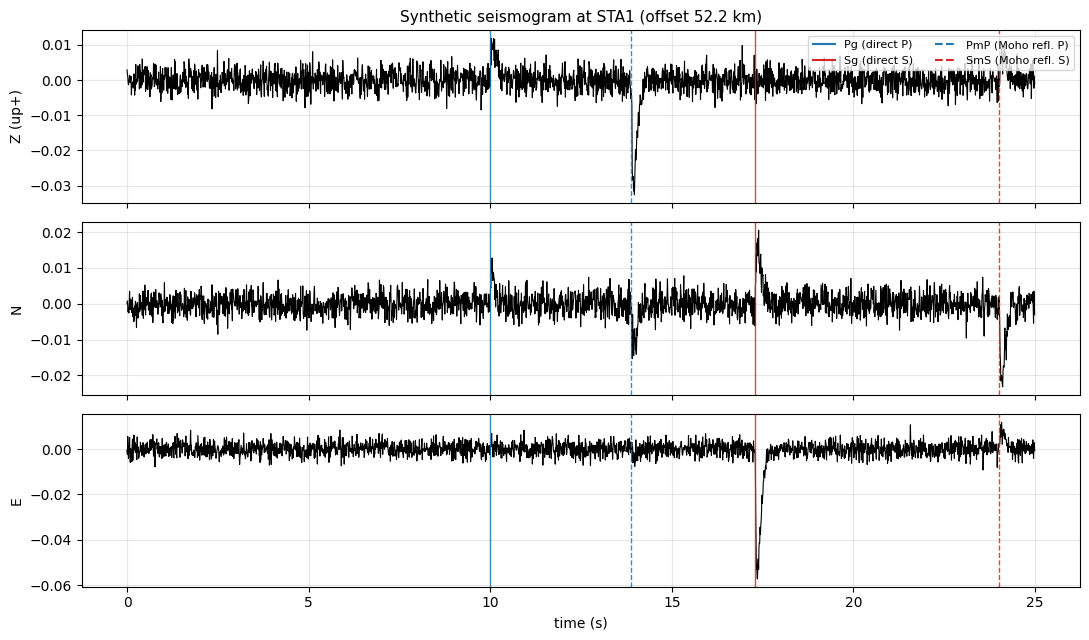

\nArrivals:
  P_direct    t =  9.997 s   sample =  1000
  S_direct    t = 17.295 s   sample =  1730
  PmP         t = 13.885 s   sample =  1388
  SmS         t = 24.021 s   sample =  2402


In [19]:
hypo = {'x': 0.0, 'y': 0.0, 'z': 8.0, 't0': 0.0}
mech = {'strike': 30, 'dip': 60, 'rake': -90, 'M0': 1.0}
station = {'name': 'STA1', 'x': 50.0, 'y': 15.0, 'z': 0.0}

seis = synthesize_seismogram(hypo, station, VMODEL, mech,
                             dt=0.01, duration=25.0, fc=2.5,
                             noise_level=0.05,
                             rng=np.random.default_rng(7))

fig, axs = plt.subplots(3, 1, figsize=(11, 6.5), sharex=True)
phase_colors = {'P_direct': 'C0', 'S_direct': 'C3', 'PmP': 'C0', 'SmS': 'C3'}
phase_styles = {'P_direct': '-', 'S_direct': '-', 'PmP': '--', 'SmS': '--'}
for ax, comp, name in zip(axs, ['Z', 'N', 'E'], ['Z (up+)', 'N', 'E']):
    ax.plot(seis['t'], seis[comp], 'k', lw=0.8)
    for ar in seis['arrivals']:
        ax.axvline(ar['arrival_time'], color=phase_colors[ar['label']],
                   ls=phase_styles[ar['label']], lw=1.0, alpha=0.85)
    ax.set_ylabel(name)
    ax.grid(alpha=0.3)
# Add legend on top axis.
from matplotlib.lines import Line2D
legend_lines = [
    Line2D([0],[0], color='C0', ls='-',  label='Pg (direct P)'),
    Line2D([0],[0], color='C3', ls='-',  label='Sg (direct S)'),
    Line2D([0],[0], color='C0', ls='--', label='PmP (Moho refl. P)'),
    Line2D([0],[0], color='C3', ls='--', label='SmS (Moho refl. S)'),
]
axs[0].legend(handles=legend_lines, loc='upper right', fontsize=8, ncol=2)
axs[0].set_title(f'Synthetic seismogram at {station["name"]}'
                 f' (offset {np.hypot(station["x"]-hypo["x"], station["y"]-hypo["y"]):.1f} km)',
                 fontsize=11)
axs[-1].set_xlabel('time (s)')
plt.tight_layout()
plt.show()

print('\\nArrivals:')
for ar in seis['arrivals']:
    print(f"  {ar['label']:10s}  t = {ar['arrival_time']:6.3f} s   "
          f"sample = {ar['sample_idx']:5d}")

## 10. A network of stations

For inversion we need many stations that *azimuthally surround* the
event. A poor station distribution (all on one side) leaves the
location poorly constrained. We deploy 8 stations at varying ranges
and azimuths.

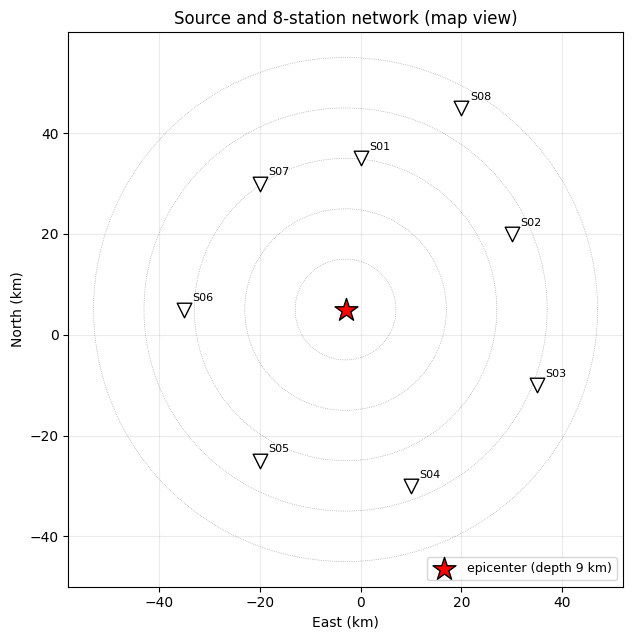

In [20]:
# Hypocenter (the truth we will try to recover later).
TRUE_HYPO = {'x': 5.0, 'y': -3.0, 'z': 9.0, 't0': 0.0}
TRUE_MECH = {'strike': 30, 'dip': 65, 'rake': -85, 'M0': 1.0}

# 8 stations spread around the source.
STATIONS = [
    {'name': 'S01', 'x':  35.0, 'y':   0.0, 'z': 0.0},
    {'name': 'S02', 'x':  20.0, 'y':  30.0, 'z': 0.0},
    {'name': 'S03', 'x': -10.0, 'y':  35.0, 'z': 0.0},
    {'name': 'S04', 'x': -30.0, 'y':  10.0, 'z': 0.0},
    {'name': 'S05', 'x': -25.0, 'y': -20.0, 'z': 0.0},
    {'name': 'S06', 'x':   5.0, 'y': -35.0, 'z': 0.0},
    {'name': 'S07', 'x':  30.0, 'y': -20.0, 'z': 0.0},
    {'name': 'S08', 'x':  45.0, 'y':  20.0, 'z': 0.0},
]

# Map view of source + stations.
fig, ax = plt.subplots(1, 1, figsize=(6.5, 6.5))
ax.scatter(TRUE_HYPO['y'], TRUE_HYPO['x'], marker='*', s=300, c='red',
           edgecolor='k', label=f'epicenter (depth {TRUE_HYPO["z"]:.0f} km)', zorder=5)
for s in STATIONS:
    ax.scatter(s['y'], s['x'], marker='v', s=110, c='white', edgecolor='k', zorder=4)
    ax.annotate(s['name'], (s['y'], s['x']), xytext=(6, 6), textcoords='offset points',
                fontsize=8)
# Range circles.
for r in (10, 20, 30, 40, 50):
    th = np.linspace(0, 2*np.pi, 200)
    ax.plot(TRUE_HYPO['y'] + r*np.cos(th), TRUE_HYPO['x'] + r*np.sin(th),
            'k:', lw=0.5, alpha=0.4)
ax.set_xlabel('East (km)')
ax.set_ylabel('North (km)')
ax.set_aspect('equal')
ax.set_title('Source and 8-station network (map view)')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

**Synthesize seismograms at every station** and plot a waterfall: each
trace stacked vertically, ordered by epicentral distance. The P and S
arrivals form clear move-out curves — that's the data the inversion
will fit.

In [ ]:
NETWORK = {}
rng = np.random.default_rng(42)
for s in STATIONS:
    seis = synthesize_seismogram(
        TRUE_HYPO, s, VMODEL, TRUE_MECH,
        dt=0.01, duration=25.0, fc=2.5,
        noise_level=0.04, rng=rng,
    )
    seis['offset'] = np.hypot(s['x']-TRUE_HYPO['x'], s['y']-TRUE_HYPO['y'])
    NETWORK[s['name']] = seis

# Waterfall plot of Z components, ordered by distance.
ordered = sorted(NETWORK.items(), key=lambda kv: kv[1]['offset'])
fig, ax = plt.subplots(1, 1, figsize=(11, 7))
peak = max(np.max(np.abs(s['Z'])) for _, s in ordered)
spacing = peak * 1.5
for i, (name, seis) in enumerate(ordered):
    y0 = i * spacing
    ax.plot(seis['t'], y0 + seis['Z'], 'k', lw=0.6)
    # Mark P and S arrivals.
    for ar in seis['arrivals']:
        if ar['label'] in ('P_direct', 'S_direct'):
            color = 'C0' if ar['is_P'] else 'C3'
            ax.plot(ar['arrival_time'], y0, marker='|', ms=18,
                    color=color, mew=2)
    ax.text(-0.3, y0, f"{name}\n{seis['offset']:.1f} km",
            ha='right', va='center', fontsize=8)

# Legend marks.
from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0],[0], color='C0', marker='|', ms=15, lw=0, label='P arrival'),
    Line2D([0],[0], color='C3', marker='|', ms=15, lw=0, label='S arrival'),
], loc='upper right', fontsize=9)
ax.set_yticks([])
ax.set_xlabel('time (s)')
ax.set_xlim(-1, 22)
ax.set_title('Network seismograms (Z component) — stations ordered by epicentral distance',
             fontsize=11)
plt.tight_layout()
plt.show()

## 11. Save the synthetic data for Notebook 02 (picking)

We pickle the network, the velocity model, and the (still-secret)
ground-truth hypocenter. The picking notebook will load `network.pkl`,
let you pick P and S onsets *by sample index*, and save those picks.
The inversion notebooks (03–06) will then try to recover `TRUE_HYPO`
from your picks alone.

In [ ]:
DATA_DIR = '../data'
os.makedirs(DATA_DIR, exist_ok=True)

# Strip down each seismogram to what the picker needs (ground truth kept
# in a separate file so the student can validate after picking).
network_for_picking = {
    name: {
        'station': seis['station'],
        'dt': seis['dt'],
        'offset': seis['offset'],
        't': seis['t'],
        'Z': seis['Z'],
        'N': seis['N'],
        'E': seis['E'],
    } for name, seis in NETWORK.items()
}

with open(os.path.join(DATA_DIR, 'network.pkl'), 'wb') as f:
    pickle.dump({
        'network': network_for_picking,
        'vmodel':  VMODEL,
        'stations': STATIONS,
    }, f)

# Ground truth — used by inversion notebooks to evaluate accuracy.
ground_truth = {
    'hypo': TRUE_HYPO,
    'mech': TRUE_MECH,
    'arrivals': {name: seis['arrivals'] for name, seis in NETWORK.items()},
}
with open(os.path.join(DATA_DIR, 'ground_truth.pkl'), 'wb') as f:
    pickle.dump(ground_truth, f)

print('Saved:')
print('  data/network.pkl       -- 8-station synthetic seismograms')
print('  data/ground_truth.pkl  -- true hypocenter + arrival times (for validation)')

Saved:
  data/network.pkl       -- 8-station synthetic seismograms
  data/ground_truth.pkl  -- true hypocenter + arrival times (for validation)


## Summary

We built the full forward operator from the velocity model up:

1. `velocity_at(z, vmodel, phase)` — 1D layered velocities.
2. `segment_travel_time(p1, p2, vmodel, phase)` — straight-segment time across layers.
3. `perturb_node`, `trace_ray` — pseudo-bending under Fermat's principle.
4. `travel_time_layered` — fast analytical (Snell) travel time, sub-millisecond agreement with pseudo-bending.
5. `moment_tensor_sdr`, `radiation_pattern`, `beachball` — double-couple source.
6. `trace_moho_reflection` — PmP / SmS phases.
7. `brune_stf`, `synthesize_seismogram` — 3-component synthetic.
8. A network of 8 stations with realistic-looking traces.

**Next:** Notebook 02 — pick the P and S arrivals on each station by
sample index. Then Notebooks 03–06 invert your picks for the
hypocenter using grid search, PSO, GA, and SA in turn.